# Oxford-IIIT Pet — error_analysis

### Загрузка лучшей модели из прошлого урока

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

raw_dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    download=True,
)

labels = np.array([raw_dataset[i][1] for i in range(len(raw_dataset))])

train_indices, val_indices = train_test_split(
    np.arange(len(raw_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

class_names = raw_dataset.classes
weights = ResNet18_Weights.IMAGENET1K_V1
resnet_transform = weights.transforms()

resnet_train_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_transform,
    download=False,
)

resnet_val_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_transform,
    download=False,
)

resnet_train_dataset = Subset(resnet_train_source, train_indices.tolist())
resnet_val_dataset = Subset(resnet_val_source, val_indices.tolist())

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42),
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

loss_fn = nn.CrossEntropyLoss()

print("Train:", len(resnet_train_dataset))
print("Validation:", len(resnet_val_dataset))
print("Classes:", len(class_names))

Device: cuda


100%|██████████| 792M/792M [00:29<00:00, 26.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.1MB/s]


Train: 2944
Validation: 736
Classes: 37


In [2]:
# Функция обучения
def train_head_one_epoch(
    model, dataloader, loss_fn, optimizer, device
):
  model.eval()
  model.fc.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)
    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  return (
      total_loss / total_objects,
      total_correct / total_objects
  )


  # Функция оценки
def evaluate_metrics(model, dataloader, loss_fn, device, num_classes):
  model.eval()

  total_loss = 0.0
  total_correct = 0
  total_top3_correct = 0
  total_objects = 0

  all_labels = []
  all_predictions = []

  with torch.inference_mode():
      for images, labels in dataloader:
          images = images.to(device)
          labels = labels.to(device)

          logits = model(images)
          loss = loss_fn(logits, labels)

          predictions = logits.argmax(dim=1)
          top3 = logits.topk(k=3, dim=1).indices

          batch_size = labels.size(0)

          total_loss += loss.item() * batch_size
          total_correct += (predictions == labels).sum().item()
          total_top3_correct += (
              (top3 == labels.unsqueeze(1))
              .any(dim=1)
              .sum()
              .item()
          )
          total_objects += batch_size

          all_labels.extend(labels.cpu().tolist())
          all_predictions.extend(predictions.cpu().tolist())

  macro_f1 = f1_score(
      all_labels,
      all_predictions,
      labels=list(range(num_classes)),
      average="macro",
      zero_division=0,
  )

  return {
      "loss": total_loss / total_objects,
      "accuracy": total_correct / total_objects,
      "macro_f1": macro_f1,
      "top3_accuracy": total_top3_correct / total_objects,
  }

In [3]:
# Мягкая аугментация (только для train)
resnet_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Validation-преобразования оставим прежними и детерменированными
resnet_val_transform = weights.transforms()


aug_train_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_train_transform,
    download=False,
)

aug_val_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_val_transform,
    download=False,
)


aug_train_dataset = Subset(
    aug_train_source,
    train_indices.tolist()
)

aug_val_dataset = Subset(
    aug_val_source,
    val_indices.tolist()
)


aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42)
)

aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [4]:
# Функция обучения для layer4 и fc
def train_layer4_one_epoch(
    model, dataloader, loss_fn, optimizer, device
):
  # Замороженная часть остается в eval
  model.eval()

  # Дообучаемые части переводим в train
  model.fc.train()
  model.layer4.train()

  total_loss = 0.0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  return (
      total_loss / total_objects,
      total_correct / total_objects
  )

In [5]:
# Базовая модель
seed_everything(42)
resnet_train_loader.generator.manual_seed(42)

resnet_model = resnet18(weights=weights)

for parameter in resnet_model.parameters():
  parameter.requires_grad = False

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    len(class_names),
)

resnet_model = resnet_model.to(device)

# Передаем оптимизатору только параметры последнего слоя
resnet_optimizer = torch.optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001,
)
loss_fn = nn.CrossEntropyLoss()

resnet_checkpoint_path = Path(
    "checkpoints/resnet18_head.pth"
)

resnet_checkpoint_path.parent.mkdir(
    parents=True, exist_ok=True
)

resnet_history = []

best_macro_f1 = -float("inf")
best_epoch = None
epochs_without_improvement = 0

max_epochs = 15
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_head_one_epoch(
      resnet_model,
      resnet_train_loader,
      loss_fn,
      resnet_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      resnet_model,
      resnet_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  resnet_history.append({
      'epoch': epoch,
      'train_loss': train_loss,
      'train_accuracy': train_accuracy,
      'val_loss': metrics["loss"],
      'val_accuracy': metrics['accuracy'],
      'val_macro_f1': metrics['macro_f1'],
      'val_top3_accuracy': metrics['top3_accuracy'],
  })

  status = ""

  if metrics['macro_f1'] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics['macro_f1']
    best_epoch = epoch
    epochs_without_improvement = 0

    torch.save({
        'model_state_dict': resnet_model.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
        'class_names': class_names,
        'weights': 'IMAGENET1K_V1',
    }, resnet_checkpoint_path)

    status = 'saved'

  else:
    epochs_without_improvement += 1
    status = (
        f"No improvement: "
        f"{epochs_without_improvement}/{patience}"
    )

  print(
      f"Epoch {epoch}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


Epoch 1/15 | Train loss: 1.8055 | Train accuracy: 60.70% | Val loss: 0.8145 | Val accuracy: 86.41% | Val macro-F1: 0.8609 | saved
Epoch 2/15 | Train loss: 0.5829 | Train accuracy: 89.61% | Val loss: 0.5030 | Val accuracy: 89.95% | Val macro-F1: 0.8996 | saved
Epoch 3/15 | Train loss: 0.3822 | Train accuracy: 92.70% | Val loss: 0.4020 | Val accuracy: 90.08% | Val macro-F1: 0.9011 | saved
Epoch 4/15 | Train loss: 0.2926 | Train accuracy: 94.29% | Val loss: 0.3547 | Val accuracy: 90.08% | Val macro-F1: 0.9008 | No improvement: 1/3
Epoch 5/15 | Train loss: 0.2381 | Train accuracy: 95.75% | Val loss: 0.3170 | Val accuracy: 91.58% | Val macro-F1: 0.9163 | saved
Epoch 6/15 | Train loss: 0.1986 | Train accuracy: 96.33% | Val loss: 0.3157 | Val accuracy: 91.17% | Val macro-F1: 0.9117 | No improvement: 1/3
Epoch 7/15 | Train loss: 0.1695 | Train accuracy: 97.11% | Val loss: 0.2867 | Val accuracy: 91.71% | Val macro-F1: 0.9173 | saved
Epoch 8/15 | Train loss: 0.1472 | Train accuracy: 97.62% | Val

In [6]:
seed_everything(42)
aug_train_loader.generator.manual_seed(42)

head_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location='cpu',
    weights_only=True,
)

aug_fine_tune_model = resnet18(weights=None)

aug_fine_tune_model.fc = nn.Linear(
    aug_fine_tune_model.fc.in_features,
    len(class_names)
)

aug_fine_tune_model.load_state_dict(
    head_checkpoint["model_state_dict"]
)

for parameter in aug_fine_tune_model.parameters():
  parameter.requires_grad=False

for parameter in aug_fine_tune_model.layer4.parameters():
  parameter.requires_grad=True

for parameter in aug_fine_tune_model.fc.parameters():
  parameter.requires_grad=True


aug_fine_tune_model = aug_fine_tune_model.to(device)

aug_fine_tune_optimizer = torch.optim.Adam([
    {
        "params": aug_fine_tune_model.layer4.parameters(),
        "lr": 1e-5,
    },
    {
        "params": aug_fine_tune_model.fc.parameters(),
        "lr": 1e-4,
    }
])


In [7]:
aug_fine_tune_checkpoint_path = Path(
    "checkpoints/resnet18_layer4_augmented.pth"
)

aug_fine_tune_history = []

best_macro_f1 = head_checkpoint["metrics"]["macro_f1"]
best_epoch = 0
epochs_without_improvement = 0

max_epochs = 15
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_head_one_epoch(
      aug_fine_tune_model,
      aug_train_loader,
      loss_fn,
      aug_fine_tune_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      aug_fine_tune_model,
      aug_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  aug_fine_tune_history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics["loss"],
      "val_accuracy": metrics["accuracy"],
      "val_macro_f1": metrics["macro_f1"],
      "val_top3_accuracy": metrics["top3_accuracy"],
  })

  if metrics['macro_f1'] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics['macro_f1']
    best_epoch = epoch
    epochs_without_improvement = 0
    status = 'saved'

    torch.save(
        {
            "model_state_dict": aug_fine_tune_model.state_dict(),
            "optimizer_state_dict": aug_fine_tune_optimizer.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names,
            "weights": "IMAGENET1K_V1",
            "stage": "layer4_fc_fine_tuning",
        },
        aug_fine_tune_checkpoint_path
    )

  else:
      epochs_without_improvement += 1
      status = (
          f"No improvement: "
          f"{epochs_without_improvement}/{patience}"
      )

  print(
      f"Epoch {epoch}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
      print("Early stopping")
      break

print("Best F1-macro:", best_macro_f1)

Epoch 1/15 | Train loss: 0.1213 | Train accuracy: 96.47% | Val loss: 0.2296 | Val accuracy: 93.75% | Val macro-F1: 0.9377 | saved
Epoch 2/15 | Train loss: 0.0817 | Train accuracy: 97.52% | Val loss: 0.2417 | Val accuracy: 92.26% | Val macro-F1: 0.9230 | No improvement: 1/3
Epoch 3/15 | Train loss: 0.0513 | Train accuracy: 98.91% | Val loss: 0.2669 | Val accuracy: 91.58% | Val macro-F1: 0.9160 | No improvement: 2/3
Epoch 4/15 | Train loss: 0.0390 | Train accuracy: 99.08% | Val loss: 0.2600 | Val accuracy: 92.53% | Val macro-F1: 0.9259 | No improvement: 3/3
Early stopping
Best F1-macro: 0.9376872519675142


# Новая тема - Error analysis

## Загружаем лучшие веса сохраненной модели

In [11]:
checkpoint = torch.load(
    aug_fine_tune_checkpoint_path,
    map_location=device,
    weights_only=True,
)

assert list(checkpoint["class_names"]) == list(class_names)

aug_fine_tune_model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded epoch:", checkpoint['epoch'])

Loaded epoch: 1


## Собираем все предсказания

In [12]:
@torch.inference_mode()
def collect_predictions(model, dataloader,device):
  model.eval()

  all_labels = []
  all_predictions = []

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    logits = model(images)
    predictions = logits.argmax(dim=1)

    all_labels.append(labels.cpu())
    all_predictions.append(predictions.cpu())

  return (
      torch.cat(all_labels).numpy(),
      torch.cat(all_predictions).numpy()
  )


y_true, y_pred = collect_predictions(
    aug_fine_tune_model,
    aug_val_loader,
    device
)

print("Number of images:", len(y_true))
print("Correct:", int((y_true == y_pred).sum()))
print("Errors:", int((y_true != y_pred).sum()))
print("Accuracy:", (y_true == y_pred).mean())

Number of images: 736
Correct: 690
Errors: 46
Accuracy: 0.9375


## Метрики по породам

In [13]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_metrics = pd.DataFrame(
    {
        "class_name": name,
        "precision": report[name]['precision'],
        "recall": report[name]["recall"],
        "f1": report[name]["f1-score"],
        "support": int(report[name]["support"])
    }
    for name in class_names
)

worst_classes  = per_class_metrics.sort_values(
    by=["f1", "recall"],
    ascending=True
)

display(worst_classes.head(10).round(3))

,class_name,precision,recall,f1,support
26,Ragdoll,0.789,0.750,0.769,20
1,American Bulldog,0.750,0.900,0.818,20
6,Birman,0.750,0.900,0.818,20
0,Abyssinian,0.938,0.750,0.833,20
13,English Setter,0.895,0.850,0.872,20
27,Russian Blue,0.857,0.900,0.878,20
32,Siamese,1.000,0.800,0.889,20
8,Boxer,0.944,0.850,0.895,20
5,Bengal,0.833,1.000,0.909,20
12,English Cocker Spaniel,1.000,0.842,0.914,19


### Матрица ошибок

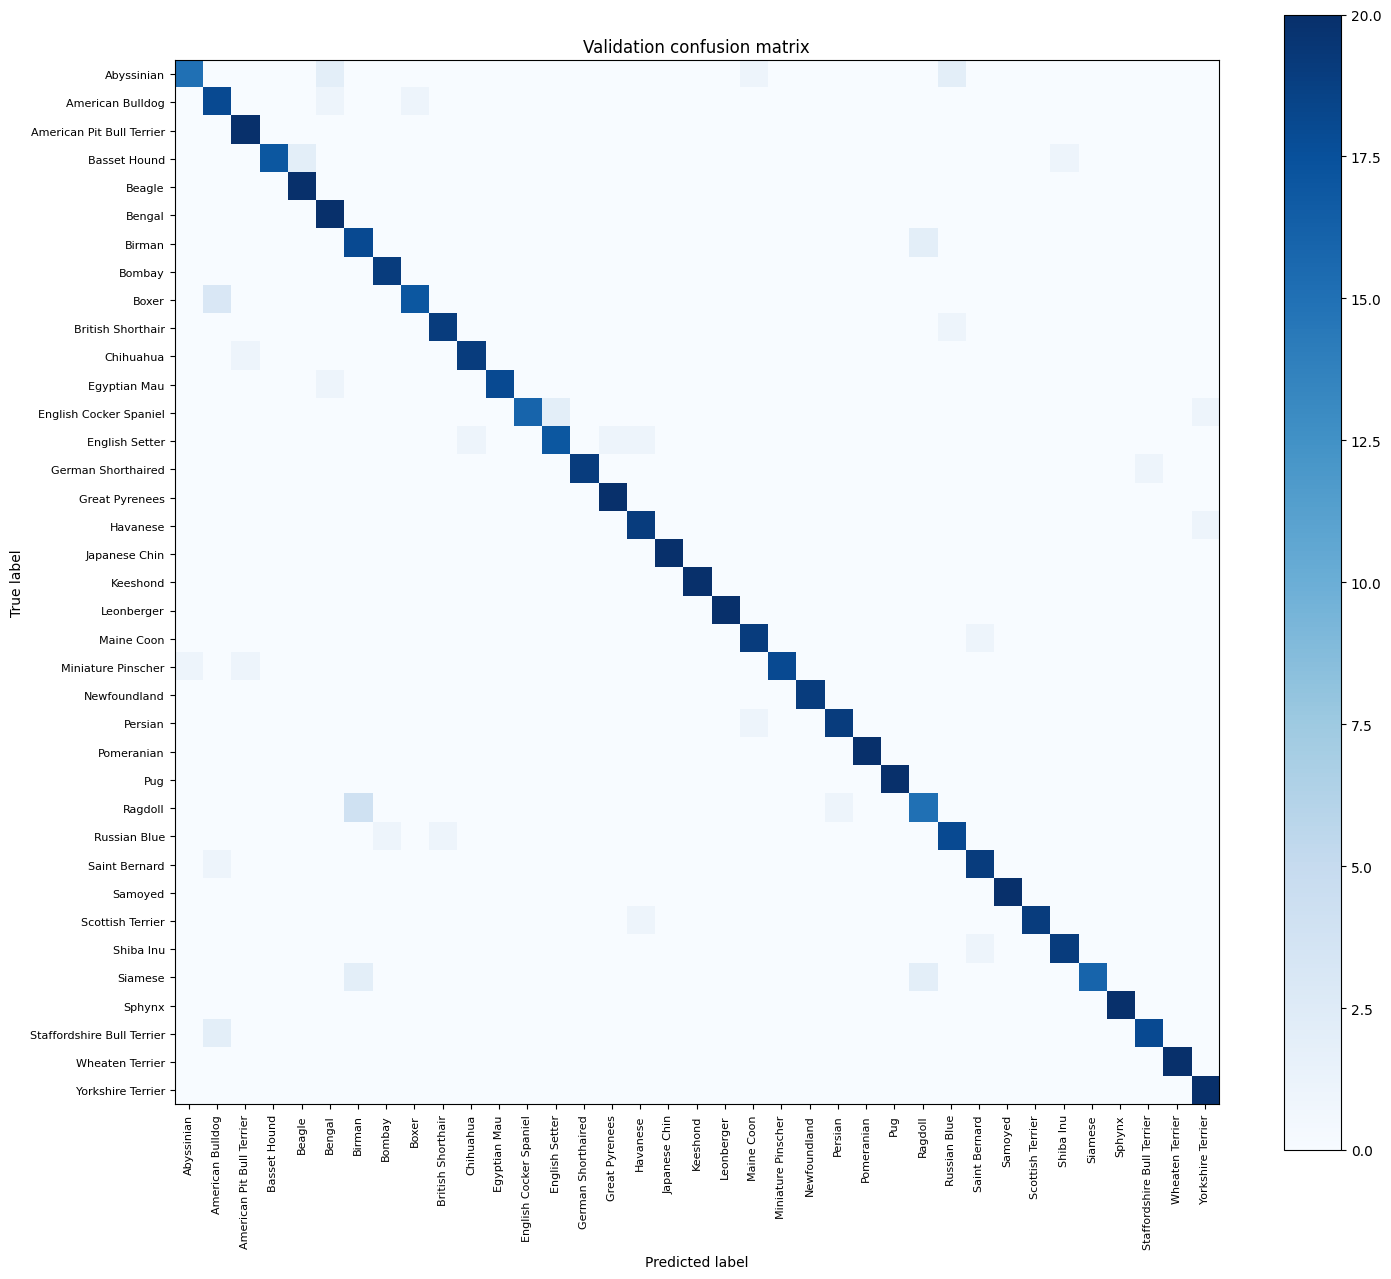

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(class_names)))
)

fig, ax = plt.subplots(figsize=(15, 13))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
).plot(
    ax=ax,
    cmap="Blues",
    include_values=False,
    xticks_rotation=90,
    colorbar=True,
)

ax.set_title("Validation confusion matrix")
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()

**Самые частые ошибки**

In [20]:
confusion_pairs = []

for true_class in range(len(class_names)):
  for predicted_class in range(len(class_names)):
    count = int(cm[true_class, predicted_class])

    # пропуск правильных ответов и пустых ячеек
    if true_class == predicted_class or count == 0:
      continue

    confusion_pairs.append({
        "true_class": class_names[true_class],
        "predicted_class": class_names[predicted_class],
        "count": count
    })

confusion_pairs_df = pd.DataFrame(
    confusion_pairs,
    columns=["true_class", "predicted_class", "count"],
).sort_values(
    by=["count", "true_class", "predicted_class"],
    ascending=[False, True, True]
)

display(confusion_pairs_df.head(10))

,true_class,predicted_class,count
23,Ragdoll,Birman,4
8,Boxer,American Bulldog,3
0,Abyssinian,Bengal,2
2,Abyssinian,Russian Blue,2
5,Basset Hound,Beagle,2
7,Birman,Ragdoll,2
12,English Cocker Spaniel,English Setter,2
30,Siamese,Birman,2
31,Siamese,Ragdoll,2
32,Staffordshire Bull Terrier,American Bulldog,2


Смотрим насколько похожи `Birman` на `Ragdoll`

Number of errors: 4


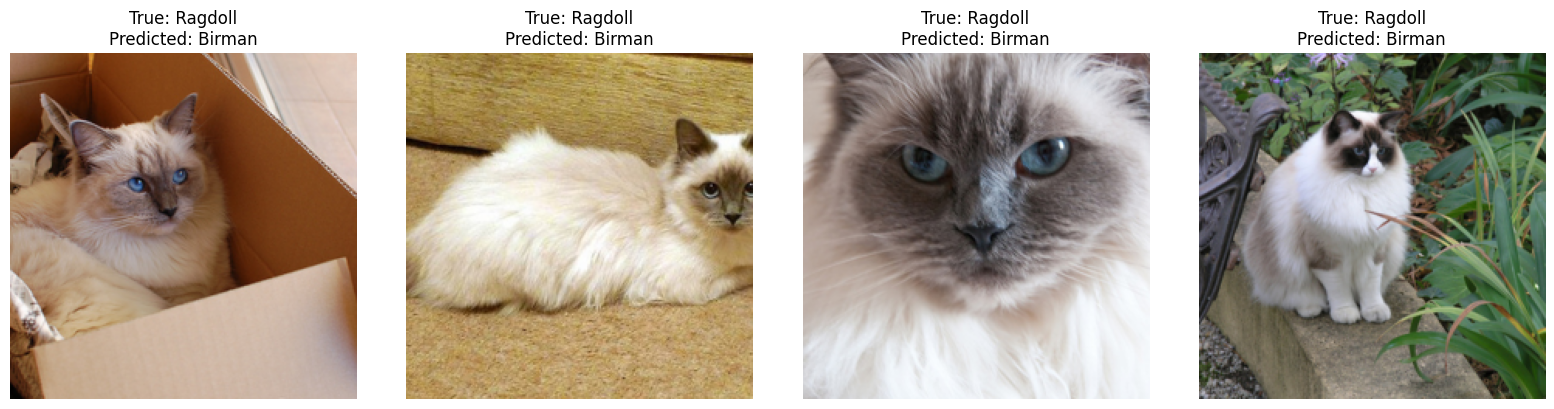

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt

true_name = "Ragdoll"
predicted_name = "Birman"

names = list(class_names)
true_id = names.index(true_name)
predicted_id = names.index(predicted_name)

error_indices = np.flatnonzero(
    (y_true == true_id) & (y_pred == predicted_id)
)

print("Number of errors:", len(error_indices))

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax in axes:
    ax.axis("off")

for ax, index in zip(axes, error_indices[:4]):
    image, label = aug_val_dataset[int(index)]

    assert int(label) == int(y_true[index])

    visible_image = (
        image.cpu() * std + mean
    ).clamp(0, 1).permute(1, 2, 0)

    ax.imshow(visible_image)
    ax.set_title(
        f"True: {names[int(label)]}\n"
        f"Predicted: {names[int(y_pred[index])]}"
    )

plt.tight_layout()
plt.show()

Number of selected images: 18


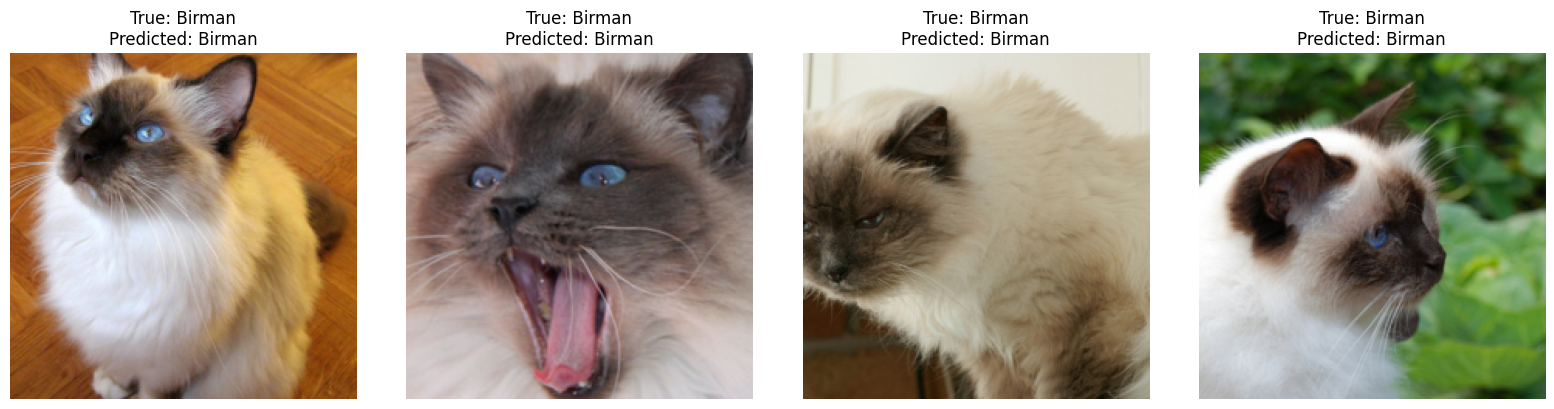

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt

true_name = "Birman"
predicted_name = "Birman"

names = list(class_names)
true_id = names.index(true_name)
predicted_id = names.index(predicted_name)

error_indices = np.flatnonzero(
    (y_true == true_id) & (y_pred == predicted_id)
)

print("Number of selected images:", len(error_indices))

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax in axes:
    ax.axis("off")

for ax, index in zip(axes, error_indices[:4]):
    image, label = aug_val_dataset[int(index)]

    assert int(label) == int(y_true[index])

    visible_image = (
        image.cpu() * std + mean
    ).clamp(0, 1).permute(1, 2, 0)

    ax.imshow(visible_image)
    ax.set_title(
        f"True: {names[int(label)]}\n"
        f"Predicted: {names[int(y_pred[index])]}"
    )

plt.tight_layout()
plt.show()

На фотографиях `Ragdoll` и `Birman` очень похожи. При этом фон, ракурсы и кадрирование различаются у правильно распознанных `Birman`. Поэтому, можно сделать вывод, что модель ошибется НЕ из=за плохих фотографий

## Финальная оценка на `test`

In [31]:
test_dataset = OxfordIIITPet(
    root="data",
    split="test",
    target_types="category",
    transform=resnet_val_transform,
    download=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

checkpoint = torch.load(
    aug_fine_tune_checkpoint_path,
    map_location=device,
    weights_only=True
)

assert list(test_dataset.classes) == list(
    checkpoint["class_names"]
)

aug_fine_tune_model.load_state_dict(
    checkpoint["model_state_dict"]
)

test_metrics = evaluate_metrics(
    aug_fine_tune_model,
    test_loader,
    loss_fn,
    device,
    num_classes=len(class_names)
)


print("Checkpoint epoch:", checkpoint["epoch"])
print("Test images:", len(test_dataset))

for name, value in test_metrics.items():
    print(f"{name}: {value:.4f}")

Checkpoint epoch: 1
Test images: 3669
loss: 0.3270
accuracy: 0.8953
macro_f1: 0.8949
top3_accuracy: 0.9864
